In [1]:
from datasets import load_dataset
from stage_1_datasets_static import (
    VLAStaticDataset,
    build_molmoact_records,
    build_sharerobot_affordance_records,
    build_sharerobot_planning_records,
    build_robovqa_records,
    build_pixmocap_records,
    build_pixmoama_records,
    build_pixmocapqa_records,
    build_robofac_records
)
from transformers import AutoProcessor

I0000 00:00:1780457162.055098     671 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780457162.824557     671 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780457165.483798     671 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Skipping import of cpp extensions due to incompatible torch ver

In [6]:
records = build_sharerobot_affordance_records()
ds = VLAStaticDataset(records)


  ShareRobot Affordance: 6,522 records


In [7]:
ds[0]["messages"]

[{'role': 'user',
  'content': [{'type': 'image',
    'image': <PIL.Image.Image image mode=RGB size=448x448>},
   {'type': 'text',
    'text': 'You are a robot manipulation assistant. Answer questions about robot tasks, object affordances, spatial relationships, and manipulation strategies based on the provided image or video frame.\n\nTask: fold a cloth\nOutput the affordance bounding box.'}]},
 {'role': 'assistant', 'content': '[479, 288, 516, 342]'}]

In [62]:
ds[1]

{'dataset': 'sharerobot_affordance',
 'type': 'qa',
 'image': [<PIL.Image.Image image mode=RGB size=448x448>],
 'messages': [{'role': 'user',
   'content': [{'type': 'image',
     'image': <PIL.Image.Image image mode=RGB size=448x448>},
    {'type': 'text',
     'text': 'You are a robot manipulation assistant. Answer questions about robot tasks, object affordances, spatial relationships, and manipulation strategies based on the provided image or video frame.\n\nTask: pick up a croissant and place it on a plate\nOutput the affordance bounding box.'}]},
  {'role': 'assistant', 'content': '[592, 167, 677, 224]'}]}

In [41]:
sample_msg = [
  {
    'role': 'user',
    'content': [
      {'type': 'image', 'image': ds[1]['messages'][0]['content'][0]['image']},
      {'type': 'text', 
       'text': (
           'You are a robot manipulation assistant. Answer questions about robot tasks, '
           'object affordances, spatial relationships, and manipulation strategies based '
           'on the provided image or video frame.\n\n'
           'Task: pick up a croissant and place it on a plate\n'
           'Output the affordance bounding box'
       )}
    ]
  }
]


In [28]:
processor = AutoProcessor.from_pretrained("/home/ubuntu/Shree_FYP/data/stage1_unsloth")

The tokenizer you are loading from '/home/ubuntu/Shree_FYP/data/stage1_unsloth' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


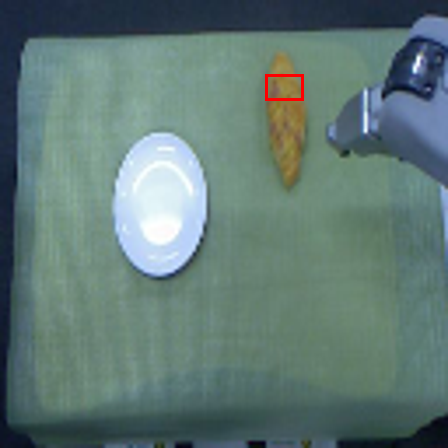

In [53]:
import ast
from PIL import ImageDraw

# 1. Grab the image (make a copy so we don't draw on the original dataset object)
image = ds[1]['messages'][0]['content'][0]['image'].copy()

# 2. Get the assistant's string output and parse it into a list
# bbox_str = ds[0]['messages'][1]['content']
# bbox_str = "[271, 245, 351, 341]"
# bbox_str = "[473, 103, 542, 363]"
# bbox_str = "[180,130,360,280]"
# bbox_str = "[480, 288, 517, 342]"
# bbox_str = "[250, 251, 327, 347]"
# bbox_str = "[540, 100, 620, 340]"
# bbox_str = "[600, 200, 670, 280]"
bbox_str = "[592, 167, 677, 224]"
bbox_1000 = ast.literal_eval(bbox_str)  # converts "[479, 288, 516, 342]" -> [479, 288, 516, 342]

width, height = image.size

# 3. Scale coordinates from 0-1000 down to the actual image size (448x448)
xmin = (bbox_1000[0] / 1000) * width
ymin = (bbox_1000[1] / 1000) * height
xmax = (bbox_1000[2] / 1000) * width
ymax = (bbox_1000[3] / 1000) * height

# 4. Draw a red rectangle
draw = ImageDraw.Draw(image)    
draw.rectangle([xmin, ymin, xmax, ymax], outline="red", width=3)

# 5. Display in Jupyter (just putting the variable at the end of the cell renders it)
image


In [24]:
from transformers import AutoModelForImageTextToText

In [25]:
import torch

In [48]:
model = AutoModelForImageTextToText.from_pretrained(
    "/home/ubuntu/Shree_FYP/data/stage1_unsloth",
    dtype = torch.bfloat16
).to("cuda")

Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

In [49]:
inputs_ids = processor.apply_chat_template(
    [sample_msg],
    tokenize = True,
    add_generation_prompt = True,
    return_dict = True,
    return_tensors = "pt"
).to("cuda")

In [50]:
with torch.no_grad():
    output = model.generate(**inputs_ids, max_new_tokens = 1028)

In [51]:
print(processor.tokenizer.decode(output[0], skip_special_tokens = True))

user
You are a robot manipulation assistant. Answer questions about robot tasks, object affordances, spatial relationships, and manipulation strategies based on the provided image or video frame.

Task: pick up a croissant and place it on a plate
Output the affordance bounding box
assistant
<think>

</think>

[600, 200, 670, 280]



In [33]:
import gc

In [46]:
del model

In [47]:
gc.collect()
torch.cuda.empty_cache()

In [105]:
from PIL import ImageDraw

def draw_point_on_image(image, point_1000, radius=6):
    """
    Draws a point on the image.
    image: PIL.Image object
    point_1000: list or tuple [x, y] scaled 0-1000
    """
    img_copy = image.copy()
    width, height = img_copy.size
    
    px = (point_1000[0] / 1000) * width
    py = (point_1000[1] / 1000) * height
    
    draw = ImageDraw.Draw(img_copy)
    draw.ellipse([px-radius, py-radius, px+radius, py+radius], fill="magenta", outline="white")
    
    return img_copy

# Usage:
# result_img = draw_point_on_image(my_image, [500, 500])
# result_img


In [106]:
res_img = draw_point_on_image(ds[0]['messages'][0]['content'][0]['image'].copy(), [260, 220])

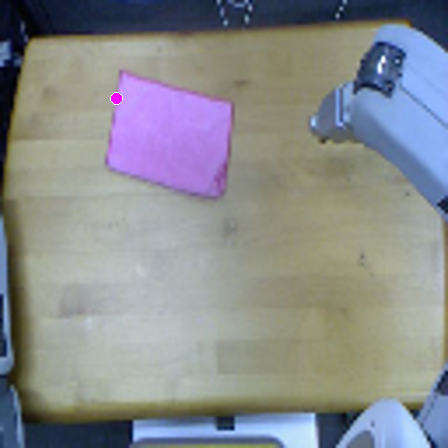

In [107]:
res_img

In [16]:
from PIL import Image

In [17]:
image = Image.open("/home/ubuntu/Shree_FYP/data/ShareRobot/affordance/images/rtx_frames_success_0/10_utokyo_pr2_tabletop_manipulation_converted_externally_to_rlds#episode_2/frame_0.png")

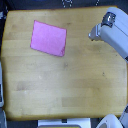

In [18]:
image

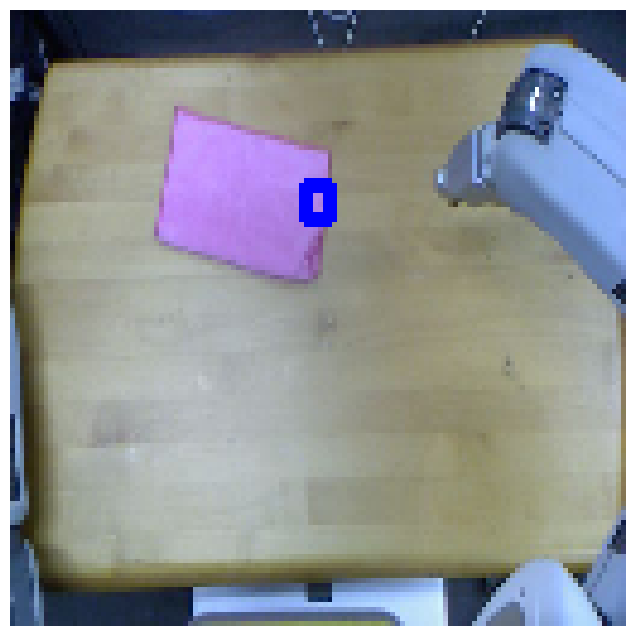

In [21]:
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

affordance_json = '/home/ubuntu/Shree_FYP/data/ShareRobot/affordance/affordance.json'

# 1. Load the affordance data and get the first item
with open(affordance_json, 'r') as f:
    data = json.load(f)
item = data[0]

# 2. Check if the image is a PIL Image and convert it to a NumPy BGR array
if isinstance(image, Image.Image):
    # Convert PIL (RGB) to NumPy (BGR) so OpenCV colors align correctly
    vis_image = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
else:
    # If it is already a NumPy array, make a copy to avoid mutating the original
    vis_image = image.copy()

color = (255, 0, 0)  # Blue in BGR
thickness = 2

x_min, y_min = item['affordance']['x'], item['affordance']['y']
x_max, y_max = item['affordance']['x'] + item['affordance']['width'], item['affordance']['y'] + item['affordance']['height']

pts = np.array([
    [x_min, y_min],
    [x_max, y_min],
    [x_max, y_max],
    [x_min, y_max]
], dtype=np.float32)

# 3. Draw the bounding box
cv2.polylines(vis_image, [pts.astype(int)], isClosed=True, color=color, thickness=thickness)

# 4. Convert back to RGB for matplotlib visualization
image_rgb = cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB)

# Visualize
plt.figure(figsize=(10, 8))
plt.imshow(image_rgb)
plt.axis('off')
plt.show()


In [22]:
import json
import os
import cv2
import numpy as np

img_dir = '/home/ubuntu/Shree_FYP/data/ShareRobot/affordance/images'
affordance_json = '/home/ubuntu/Shree_FYP/data/ShareRobot/affordance/affordance.json'
output_img_dir = '/home/ubuntu/Shree_FYP/data/ShareRobot/affordance/visualized_images'

count = 0
with open(affordance_json, 'r') as f:
    data = json.load(f)
    for item in data:
        filepath = os.path.join(img_dir, item['image_path'])
        
        image = cv2.imread(filepath)
        color = (255, 0, 0)
        thickness = 2

        x_min,y_min = item['affordance']['x'], item['affordance']['y']
        x_max,y_max = item['affordance']['x']+item['affordance']['width'], item['affordance']['y']+item['affordance']['height']

        # 定义矩形的四个顶点坐标
        pts = np.array([
            [x_min, y_min],  # 左上角
            [x_max, y_min],  # 右上角
            [x_max, y_max],  # 右下角
            [x_min, y_max]   # 左下角
        ], dtype=np.float32)

        # 绘制矩形框
        cv2.polylines(image, [pts.astype(int)], isClosed=True, color=color, thickness=thickness)

        # 获取相对路径并拼接目标路径
        relative_path = os.path.relpath(filepath, img_dir)  # 获取相对于 img_dir 的相对路径
        output_img_path = os.path.join(output_img_dir, relative_path)  # 拼接目标路径

        # 创建目标文件夹
        output_directory = os.path.dirname(output_img_path)
        if not os.path.exists(output_directory):
            os.makedirs(output_directory)

        # 打印调试信息
        print(f"Input filepath: {filepath}")
        print(f"Output image path: {output_img_path}")
        print(f"Output directory: {output_directory}")

        # 保存图像
        count += 1
        cv2.imwrite(output_img_path, image)

print(count)

Input filepath: /home/ubuntu/Shree_FYP/data/ShareRobot/affordance/images/rtx_frames_success_0/10_utokyo_pr2_tabletop_manipulation_converted_externally_to_rlds#episode_2/frame_0.png
Output image path: /home/ubuntu/Shree_FYP/data/ShareRobot/affordance/visualized_images/rtx_frames_success_0/10_utokyo_pr2_tabletop_manipulation_converted_externally_to_rlds#episode_2/frame_0.png
Output directory: /home/ubuntu/Shree_FYP/data/ShareRobot/affordance/visualized_images/rtx_frames_success_0/10_utokyo_pr2_tabletop_manipulation_converted_externally_to_rlds#episode_2
Input filepath: /home/ubuntu/Shree_FYP/data/ShareRobot/affordance/images/rtx_frames_success_0/10_utokyo_pr2_tabletop_manipulation_converted_externally_to_rlds#episode_6/frame_0.png
Output image path: /home/ubuntu/Shree_FYP/data/ShareRobot/affordance/visualized_images/rtx_frames_success_0/10_utokyo_pr2_tabletop_manipulation_converted_externally_to_rlds#episode_6/frame_0.png
Output directory: /home/ubuntu/Shree_FYP/data/ShareRobot/affordanc